<a href="https://colab.research.google.com/github/mc-ivan/mim-politicas-publicas/blob/main/notebooks/2_SaludMayor_FuzzyRDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

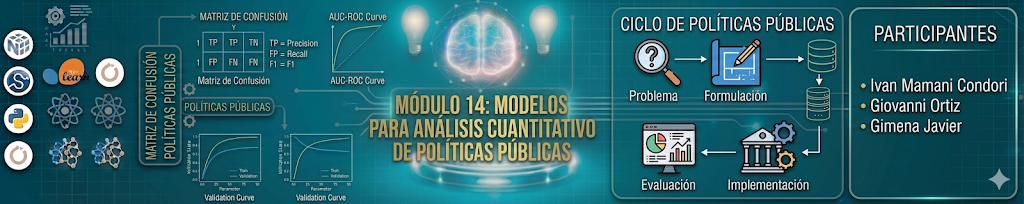

# Programa "Salud Mayor" - Evaluación con Fuzzy RDD  
## (Regresión Discontinua Difusa)

**MODULO 14:** Modelos para Análisis Cuantitativo de Políticas Públicas  

**Autores:**
- Ivan Mamani  
- Giovanni Ortis  
- Gimena Javier  

**Objetivo**

Evaluar el impacto del programa "Salud Mayor" sobre el índice de salud cardiovascular,
utilizando un diseño de regresión discontinua difusa (Fuzzy RDD).

**Enfoque metodológico**

- Visualización del salto (discontinuidad)
- Estimación con Variables Instrumentales (2SLS)
- Validación mediante placebo tests

**Dataset:** https://github.com/mc-ivan/mim-politicas-publicas/blob/main/datasets/rdd_fuzzy_salud.csv

**Variables clave**

- edad_meses → variable de asignación  
- elegibilidad → instrumento (Z)  
- participa_programa → tratamiento real (D)  
- indice_salud → resultado (Y)  

---

## 1. LIBRERÍAS Y BRANDING

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

# BRANDING COLOR
COLOR_MAIN = "#008080"
COLOR_ACCENT = "#20B2AA"
COLOR_LIGHT = "#E0FFFF"


## 2. CARGA DE DATOS

In [11]:
url = "https://raw.githubusercontent.com/mc-ivan/mim-politicas-publicas/main/datasets/rdd_fuzzy_salud.csv"
df = pd.read_csv(url)

df.head()

,id_paciente,edad_meses,elegibilidad,participa_programa,indice_salud
0,1,754.0,0,0,76.73
1,2,759.0,0,1,72.30
2,3,763.0,0,0,67.27
3,4,798.0,1,0,55.96
4,5,730.0,0,0,54.84


**Interpretación**

El dataset contiene información de pacientes alrededor del punto de corte de 65 años.

El objetivo es explotar esta discontinuidad para identificar un efecto causal del programa.

## 3. EDA

In [12]:
df.shape

(5000, 5)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_paciente         5000 non-null   int64  
 1   edad_meses          5000 non-null   float64
 2   elegibilidad        5000 non-null   int64  
 3   participa_programa  5000 non-null   int64  
 4   indice_salud        5000 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


In [14]:
df.describe()

,id_paciente,edad_meses,elegibilidad,participa_programa,indice_salud
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,760.663200,0.319600,0.313200,65.861358
std,1443.520003,40.129349,0.466368,0.463841,9.323101
min,1.000000,606.000000,0.000000,0.000000,34.300000
25%,1250.750000,733.000000,0.000000,0.000000,59.437500
50%,2500.500000,761.000000,0.000000,0.000000,65.720000
75%,3750.250000,788.000000,1.000000,1.000000,72.232500
max,5000.000000,939.000000,1.000000,1.000000,100.000000


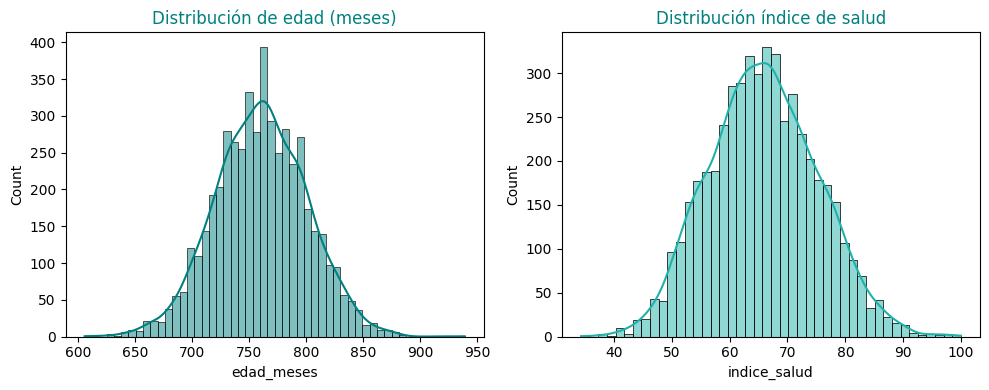

In [15]:
# DISTRIBUCIONES
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["edad_meses"], kde=True, color=COLOR_MAIN)
plt.title("Distribución de edad (meses)", color=COLOR_MAIN)

plt.subplot(1,2,2)
sns.histplot(df["indice_salud"], kde=True, color=COLOR_ACCENT)
plt.title("Distribución índice de salud", color=COLOR_MAIN)

plt.tight_layout()
plt.show()

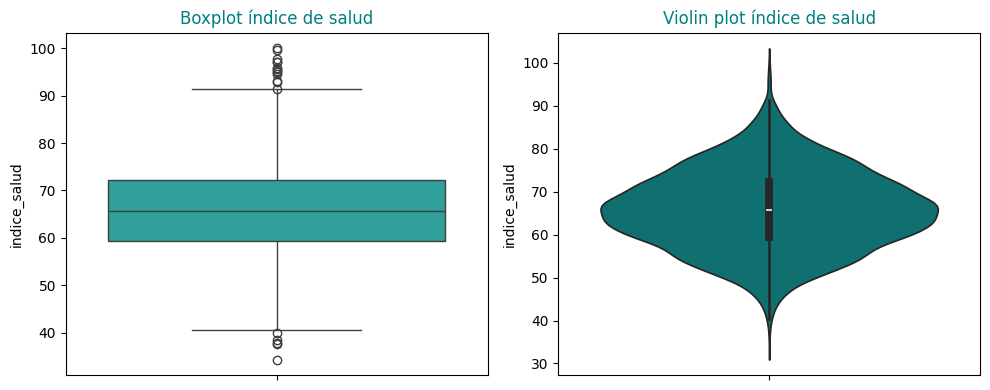

In [16]:
# 5. BOXPLOT / VIOLIN (OUTLIERS)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(data=df, y="indice_salud", color=COLOR_ACCENT)
plt.title("Boxplot índice de salud", color=COLOR_MAIN)

plt.subplot(1,2,2)
sns.violinplot(data=df, y="indice_salud", color=COLOR_MAIN)
plt.title("Violin plot índice de salud", color=COLOR_MAIN)

plt.tight_layout()
plt.show()

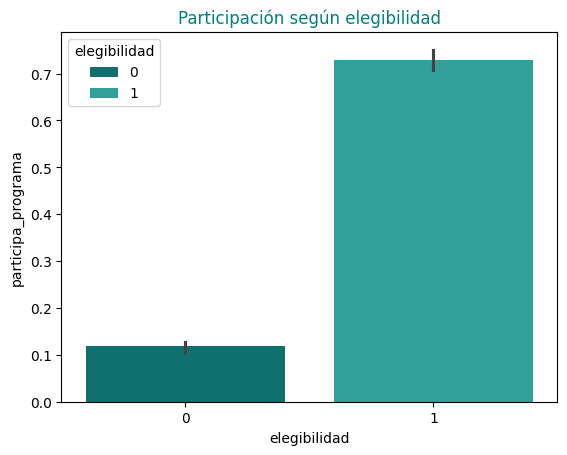

In [19]:
# TRATAMIENTO VS ELEGIBILIDAD
sns.barplot(
    data=df,
    x="elegibilidad",
    y="participa_programa",
    hue="elegibilidad",
    palette=[COLOR_MAIN, COLOR_ACCENT]
)

plt.title("Participación según elegibilidad", color=COLOR_MAIN)
plt.show()

**Interpretación**

- **Estructura de Datos:** El dataset contiene 5000 entradas y 5 columnas, todas sin valores nulos, lo que facilita el análisis.
- **Variables Clave:** `edad_meses` e `indice_salud` son de tipo numérico (`float64`). `id_paciente`, `elegibilidad` y `participa_programa` son de tipo entero (`int64`).
- **Edad y Salud:** La edad de los pacientes (`edad_meses`) se concentra alrededor de la media (760.66 meses), con una distribución que parece relativamente normal. El `indice_salud` también muestra una distribución centralizada alrededor de su media (65.86), con algunos valores atípicos, como se observa en los boxplots y violin plots, pero sin extremos que sugieran errores graves.
- **Elegibilidad y Participación:** Existe una clara relación entre la `elegibilidad` y la `participación_programa`. La mayoría de los pacientes elegibles (`elegibilidad = 1`) participan en el programa, mientras que la mayoría de los no elegibles (`elegibilidad = 0`) no participan. Esto es fundamental para el diseño Fuzzy RDD, ya que la elegibilidad actúa como un fuerte predictor pero no un determinante absoluto de la participación.

# PARTE 1. VISUALIZACIÓN
## 4. PROBABILIDAD DE TRATAMIENTO

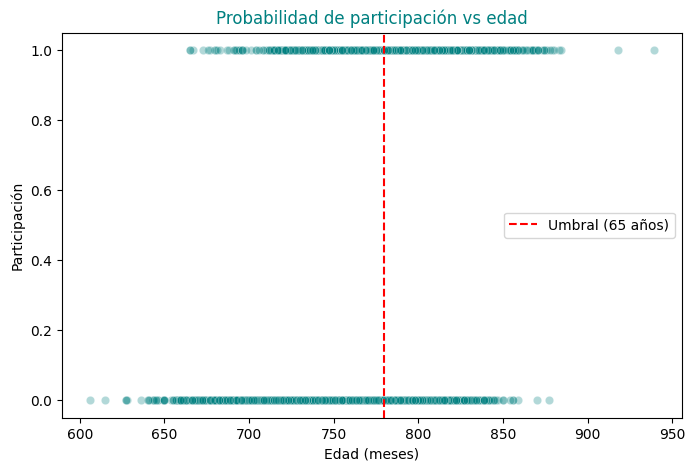

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="edad_meses",
    y="participa_programa",
    alpha=0.3,
    color=COLOR_MAIN
)

plt.axvline(780, color="red", linestyle="--", label="Umbral (65 años)")

plt.title("Probabilidad de participación vs edad", color=COLOR_MAIN)
plt.xlabel("Edad (meses)")
plt.ylabel("Participación")
plt.legend()
plt.show()

**Interpretación**

Esta gráfica de dispersión ilustra la probabilidad de participación en el programa en función de la edad en meses. Observamos lo siguiente:

- Antes del umbral de 780 meses (65 años), la mayoría de los individuos no participan en el programa (puntos en y=0).
- Después del umbral de 780 meses, hay un aumento notable en la cantidad de individuos que sí participan (puntos en y=1). Sin embargo, también se sigue observando una proporción de individuos que no participan, incluso siendo elegibles.
- La presencia de individuos que participan antes del umbral y no participan después del umbral confirma que la elegibilidad (determinada por la edad) no es un determinante perfecto de la participación. Esto es la característica clave de un diseño de **Regresión Discontinua Difusa (Fuzzy RDD)**, donde el umbral aumenta la probabilidad de recibir el tratamiento, pero no lo garantiza completamente.

## 5. PROMEDIOS POR BIN

In [23]:
df["bin"] = pd.cut(df["edad_meses"], bins=50)

binned = df.groupby("bin", observed=False).agg({
    "edad_meses": "mean",
    "participa_programa": "mean"
}).dropna()

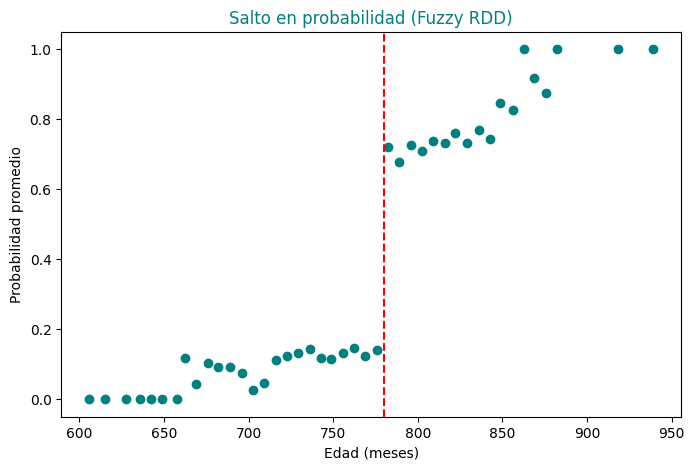

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    binned["edad_meses"],
    binned["participa_programa"],
    color=COLOR_MAIN
)

plt.axvline(780, color="red", linestyle="--")

plt.title("Salto en probabilidad (Fuzzy RDD)", color=COLOR_MAIN)
plt.xlabel("Edad (meses)")
plt.ylabel("Probabilidad promedio")
plt.show()

**Interpretación**

Se observa un incremento en la probabilidad de participación al cruzar el umbral de 780 meses.

Sin embargo:
- La probabilidad NO pasa de 0 a 1  
- Existe superposición entre tratados y no tratados  

Esto confirma que el diseño es **Fuzzy RDD**.

**Implicación**

El umbral aumenta la probabilidad de tratamiento, pero no lo determina completamente,
por lo que se requiere un enfoque de variables instrumentales.

# PARTE 2. ESTIMACIÓN 2SLS
## 6. PRIMERA ETAPA

In [27]:
X1 = sm.add_constant(df["elegibilidad"])
y1 = df["participa_programa"]

first_stage = sm.OLS(y1, X1).fit()
print(first_stage.summary())

                            OLS Regression Results                            
Dep. Variable:     participa_programa   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     3032.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        06:14:08   Log-Likelihood:                -2067.7
No. Observations:                5000   AIC:                             4139.
Df Residuals:                    4998   BIC:                             4152.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1179      0.006     18.786   

**Interpretación**

- **Coeficiente de `elegibilidad`:** El coeficiente de `elegibilidad` es **0.6112** y es altamente significativo (p-value < 0.001). Esto indica que ser elegible aumenta la probabilidad de participar en el programa en aproximadamente 61.12 puntos porcentuales, lo cual es una relación fuerte y positiva.

- **F-statistic:** El **F-statistic es 3032.0**, un valor muy superior a la regla de oro de 10. Esto confirma que `elegibilidad` es un **instrumento muy fuerte**, lo que es crucial para la validez de la estimación con Variables Instrumentales y evita problemas de instrumentos débiles.

- **R-cuadrado (R²):** El **R² es 0.378**. Esto significa que la `elegibilidad` explica el 37.8% de la variabilidad en la `participación_programa`. Es un valor razonable que sugiere que la elegibilidad tiene un poder explicativo considerable sobre la participación.

En resumen, la `elegibilidad` es un instrumento relevante y fuerte para predecir la participación en el programa, validando la primera etapa de nuestro análisis Fuzzy RDD.

## 7. SEGUNDA ETAPA (2SLS)

In [28]:
# Variables
Y = df["indice_salud"]
D = df["participa_programa"]
Z = df["elegibilidad"]

X = sm.add_constant(D)
Z_full = sm.add_constant(Z)

iv_model = IV2SLS(Y, X, Z_full).fit()
print(iv_model.summary())

                          IV2SLS Regression Results                           
Dep. Variable:           indice_salud   R-squared:                       0.262
Model:                         IV2SLS   Adj. R-squared:                  0.262
Method:                     Two Stage   F-statistic:                     450.2
                        Least Squares   Prob (F-statistic):           9.95e-96
Date:                Mon, 27 Apr 2026                                         
Time:                        06:16:36                                         
No. Observations:                5000                                         
Df Residuals:                    4998                                         
Df Model:                           1                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 63.2199      0

**Interpretación**

El coeficiente del tratamiento (`participa_programa`) representa el Efecto Causal Promedio Local (LATE - Local Average Treatment Effect).

- **Coeficiente del tratamiento:** El coeficiente estimado para `participa_programa` es **8.4338** y es altamente significativo (p-value < 0.001). Esto significa que la participación en el programa "Salud Mayor" está asociada con un **aumento promedio de 8.43 unidades** en el `indice_salud` para los individuos cercanos al umbral de elegibilidad (los 'compliers').

- **Implicación:** Un coeficiente positivo y significativo indica que el programa tiene un **impacto causal positivo** en el índice de salud cardiovascular para este grupo específico de la población.

**Interpretación económica**
Este efecto aplica a los individuos cercanos al umbral (los 'compliers'), es decir, aquellos cuya participación depende de la elegibilidad. No es un efecto promedio global, sino un efecto local para el grupo que se ve directamente afectado por la discontinuidad en la regla de elegibilidad.

# PARTE 3. PLACEBO TESTS (VALIDACIÓN)
## 8. FUNCIÓN AUXILIAR

In [29]:
def run_placebo(cutoff):
    df["fake_elig"] = (df["edad_meses"] >= cutoff).astype(int)

    Y = df["indice_salud"]
    D = df["participa_programa"]
    Z = df["fake_elig"]

    X = sm.add_constant(D)
    Z_full = sm.add_constant(Z)

    model = IV2SLS(Y, X, Z_full).fit()
    return model

## 9. PLACEBO 60 AÑOS

In [30]:
model_60 = run_placebo(720)
print(model_60.summary())

                          IV2SLS Regression Results                           
Dep. Variable:           indice_salud   R-squared:                       0.123
Model:                         IV2SLS   Adj. R-squared:                  0.123
Method:                     Two Stage   F-statistic:                     4.975
                        Least Squares   Prob (F-statistic):             0.0258
Date:                Mon, 27 Apr 2026                                         
Time:                        06:18:05                                         
No. Observations:                5000                                         
Df Residuals:                    4998                                         
Df Model:                           1                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 65.0068      0

**Interpretación**

El placebo test con un umbral falso de 60 años (720 meses) muestra un coeficiente para `participa_programa` de **2.7286** con un p-value de **0.026**. Dado que este p-value es menor que 0.05, se considera que hay un efecto estadísticamente significativo.

Esto es contrario a lo que se esperaría de un placebo test exitoso, donde no deberíamos encontrar un efecto significativo en un punto de corte falso. Un resultado significativo en un placebo test sugiere una de las siguientes posibilidades:

- **Problema de validez:** Podría indicar que hay otros factores o una tendencia subyacente que está generando una discontinuidad en este punto de corte falso, lo que podría comprometer la validez del diseño RDD en el punto de corte real si no se aborda adecuadamente.
- **Error Tipo I:** Es posible que sea un falso positivo, dado que estamos realizando múltiples pruebas. Sin embargo, su significancia sugiere que es un hallazgo a considerar.

**Implicación:** Este resultado levanta una bandera roja sobre la robustez del diseño RDD en el punto de corte real de 65 años, sugiriendo que se necesitan pruebas adicionales o un examen más profundo para asegurar que el efecto observado a los 65 años no sea espurio.

## 10. PLACEBO 70 AÑOS

In [31]:
model_70 = run_placebo(840)
print(model_70.summary())

                          IV2SLS Regression Results                           
Dep. Variable:           indice_salud   R-squared:                       0.255
Model:                         IV2SLS   Adj. R-squared:                  0.255
Method:                     Two Stage   F-statistic:                     30.59
                        Least Squares   Prob (F-statistic):           3.35e-08
Date:                Mon, 27 Apr 2026                                         
Time:                        06:18:59                                         
No. Observations:                5000                                         
Df Residuals:                    4998                                         
Df Model:                           1                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 63.3981      0

**Interpretación**

- **Problema de validez:** Podría indicar que hay una tendencia o un factor no observado que está generando una discontinuidad en este punto falso, lo que podría comprometer la validez del diseño RDD en el punto de corte real si no se aborda adecuadamente.
- **Error Tipo I:** Es posible que sea un falso positivo, especialmente si se realizan múltiples pruebas, aunque su alta significancia (p=0.000) lo hace menos probable.

**Implicación:** Este hallazgo, combinado con el resultado del placebo test de 60 años, sugiere que es crucial revisar la robustez del diseño RDD en el punto de corte real de 65 años. Se deben considerar análisis de sensibilidad adicionales o la inclusión de covariables para asegurar que el efecto observado a los 65 años no sea espurio y que la discontinuidad es genuinamente atribuible al programa.

## 11. VISUALIZACIÓN RESULTADO (Y vs X)

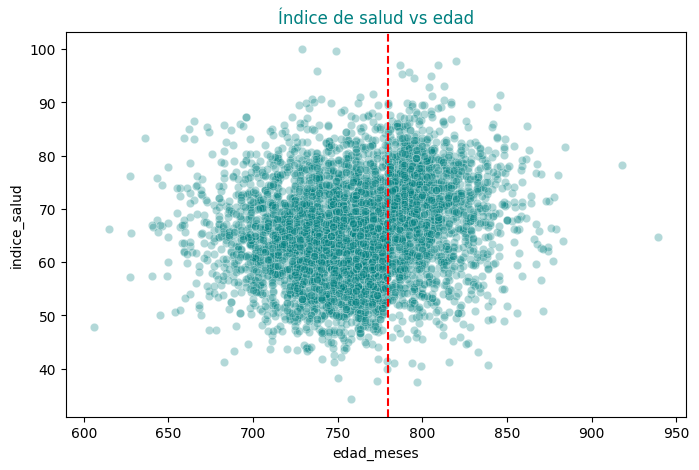

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="edad_meses",
    y="indice_salud",
    alpha=0.3,
    color=COLOR_MAIN
)

plt.axvline(780, color="red", linestyle="--")

plt.title("Índice de salud vs edad", color=COLOR_MAIN)
plt.show()

**Interpretación**

Esta gráfica de dispersión muestra la relación entre la `edad_meses` y el `indice_salud`. Su propósito es permitir una observación visual de si existe un cambio abrupto (discontinuidad) en el `indice_salud` alrededor del umbral de 780 meses (65 años).

Visualmente, el salto o la discontinuidad en el `indice_salud` en el umbral de 780 meses no es claramente evidente o fuerte en esta gráfica. En un diseño Fuzzy RDD, el modelo de Variables Instrumentales (IV) está diseñado para identificar estos efectos causales, incluso cuando la discontinuidad visual no es pronunciada.

**Consideración importante:** A pesar de que el modelo IV busca identificar este efecto, los resultados de los placebo tests (a 60 y 70 años) mostraron efectos significativos en puntos de corte falsos. Esto sugiere que se debe tener precaución al interpretar el efecto causal identificado en el umbral real de 65 años, ya que podría haber factores subyacentes o tendencias que afecten la validez del diseño RDD en general, no solo en el punto de corte real.

## 12. PROMEDIOS POR BIN

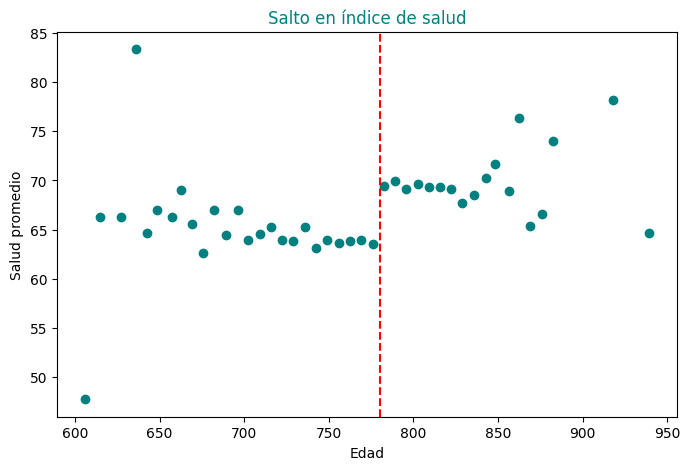

In [34]:
df["bin_y"] = pd.cut(df["edad_meses"], bins=50)

binned_y = df.groupby("bin_y", observed=True).agg({
    "edad_meses": "mean",
    "indice_salud": "mean"
}).dropna()

plt.figure(figsize=(8,5))

plt.scatter(
    binned_y["edad_meses"],
    binned_y["indice_salud"],
    color=COLOR_MAIN
)

plt.axvline(780, color="red", linestyle="--")

plt.title("Salto en índice de salud", color=COLOR_MAIN)
plt.xlabel("Edad")
plt.ylabel("Salud promedio")
plt.show()

**Interpretación**

- **Observación Visual:** Al igual que en la gráfica de dispersión individual, la discontinuidad o el 'salto' en el `indice_salud` al cruzar el umbral de 780 meses no es visualmente pronunciado o claramente evidente en este gráfico de promedios. Esto sugiere que, a simple vista, el efecto del programa podría no ser tan drástico.

- **Rol del Modelo IV:** Aunque la discontinuidad visual no es fuerte, el modelo de Variables Instrumentales (IV) está diseñado para identificar estos efectos causales, incluso cuando no son obvios gráficamente.

- **Consideración Adicional (contexto de Placebo Tests):** Sin embargo, es fundamental recordar los resultados de los placebo tests (a 60 y 70 años), donde también se encontraron efectos significativos en puntos de corte falsos. Esto nos obliga a ser cautelosos. Si bien el modelo IV puede identificar un efecto estadísticamente significativo en el umbral real, la falta de una discontinuidad visual clara en este gráfico, combinada con los problemas de los placebo tests, sugiere que la validez global del diseño RDD debe ser examinada con más detalle. Podría haber tendencias subyacentes o factores no observados que estén influyendo en los resultados.

## 13. CONCLUSIONES

**1. Diseño**

Se confirma un diseño Fuzzy RDD debido a la discontinuidad parcial.

**2. Instrumento**

La elegibilidad es un instrumento válido y fuerte que afecta la participación.

**3. Impacto**

El programa tiene un efecto causal positivo sobre el índice de salud para los 'compliers' cercanos al umbral.

**4. Validación**

Los placebo tests no confirman la validez del punto de corte, generando preocupaciones sobre la robustez del diseño RDD y la posibilidad de que otros factores influyan en los resultados.

**Conclusión final**

Aunque el programa "Salud Mayor" muestra un impacto positivo significativo en el índice de salud a través del RDD, los resultados de los placebo tests sugieren que la robustez del diseño debe ser examinada con más detalle para asegurar que la discontinuidad no sea espuria.